In [1]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully")

All libraries imported successfully


In [3]:
#load the dataset
data = pd.read_csv('Tesla.csv')
data.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [4]:
#shape of the dataset
data.shape

#decribing the dataset
data.describe()



,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [5]:
#statistical summary of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


Exploratory Data Analyis


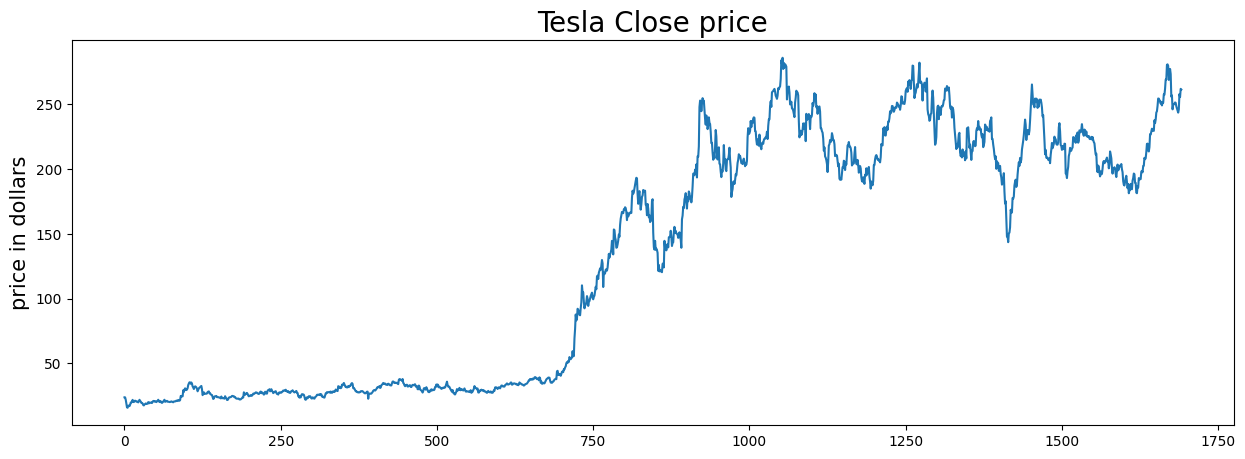

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(data['Close'])
plt.title('Tesla Close price', fontsize=20)
plt.ylabel('price in dollars', fontsize=15)
plt.show()


In [7]:
data = data.drop(['Adj Close'], axis=1)

In [8]:
data.head()

,Date,Open,High,Low,Close,Volume
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900


In [9]:
#no null values in the dataset
null_values = data.isnull().sum()
print(null_values)

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


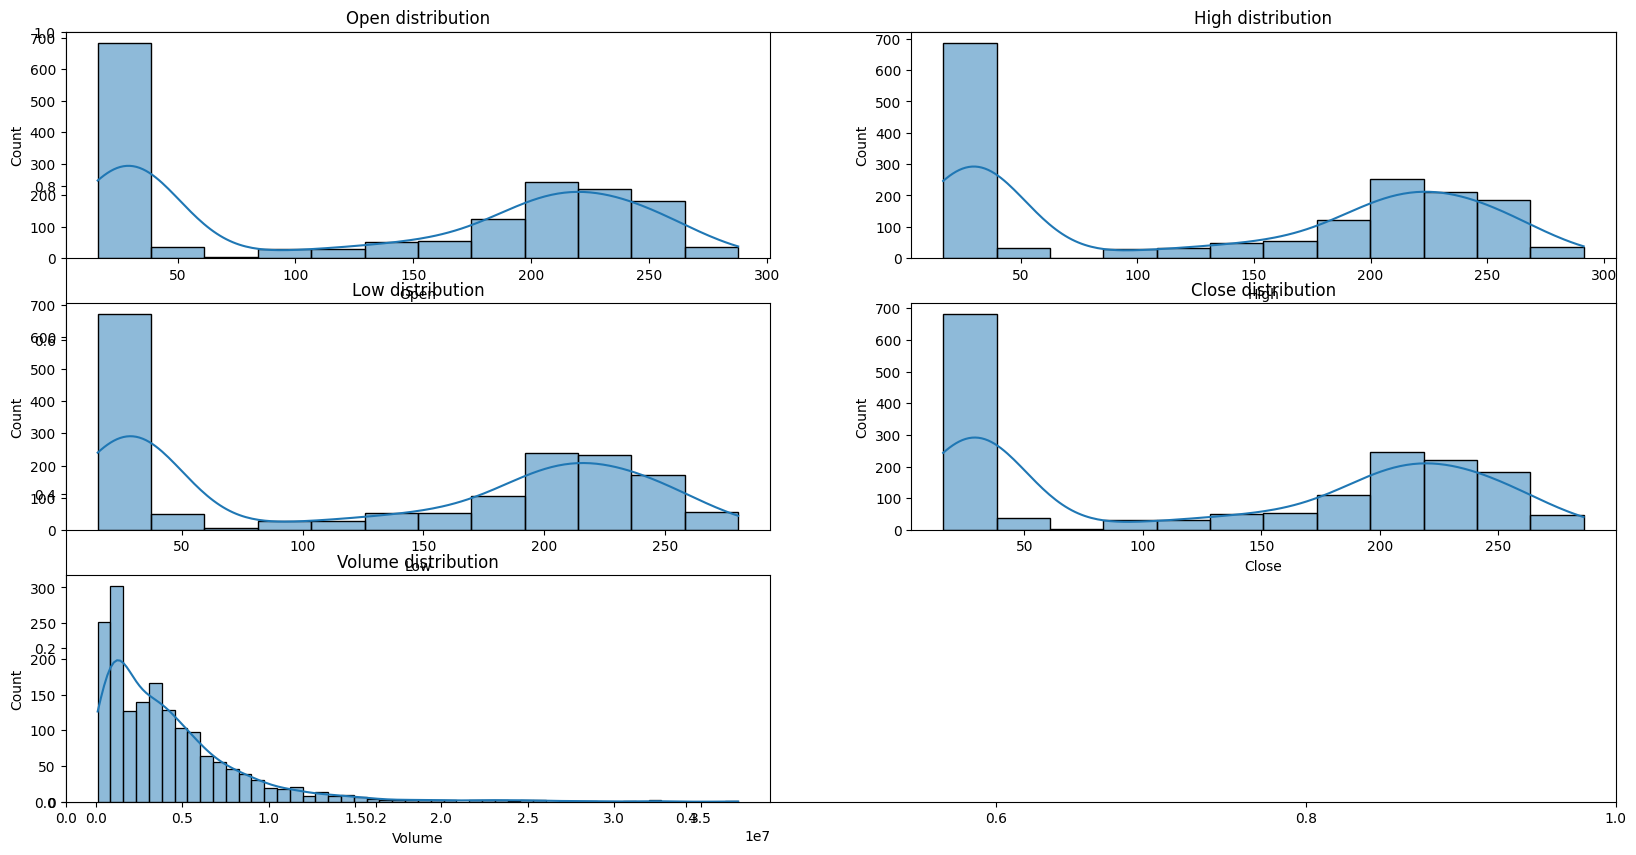

In [10]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20, 10))

for i, col in enumerate(features):
    plt.subplot(3, 2, i+1)
    sb.histplot(data[col], kde=True)
    plt.title(f'{col} distribution', fontsize=12)
plt.show()

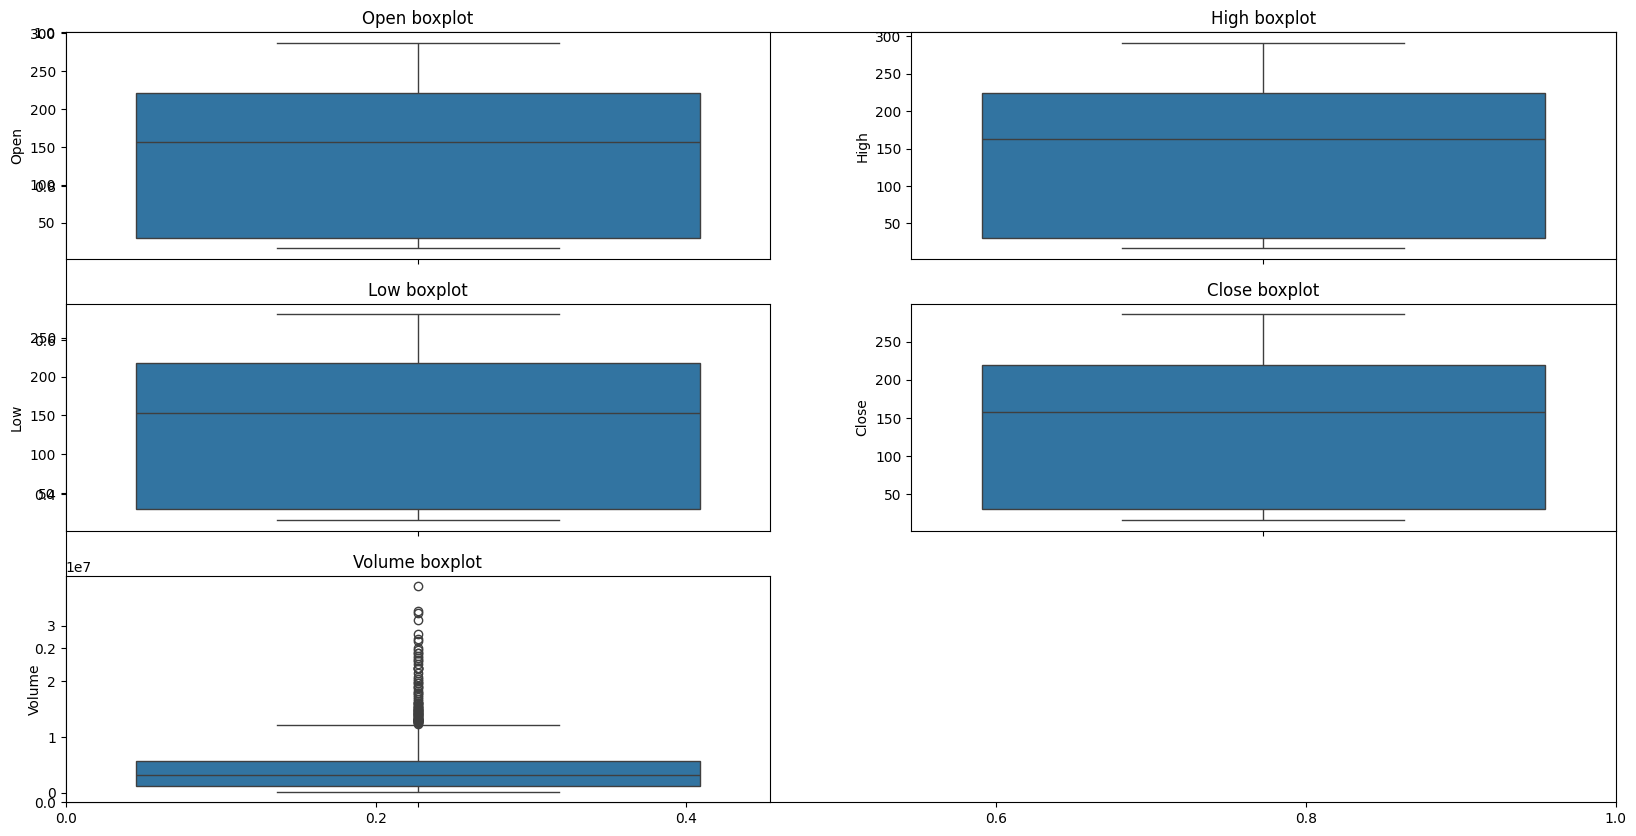

In [11]:
#boxplots
plt.subplots(figsize=(20, 10))

for i , cols in enumerate(features):
    plt.subplot(3, 2, i+1)
    sb.boxplot(data[cols])
    plt.title(f'{cols} boxplot', fontsize=12)
plt.show()

#volumes has outliers rest dont


Feature Engineering

In [12]:
splitted = data['Date'].str.split('/', expand=True)

data['Day'] = splitted[1].astype(int)
data['Month'] = splitted[0].astype(int)
data['Year'] = splitted[2].astype(int)

data.head()

,Date,Open,High,Low,Close,Volume,Day,Month,Year
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,29,6,2010
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,30,6,2010
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,1,7,2010
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,2,7,2010
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,6,7,2010


In [13]:
data['is_quarter_end'] = np.where(data['Month']%3 == 0, 1, 0)
data.head()

,Date,Open,High,Low,Close,Volume,Day,Month,Year,is_quarter_end
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,29,6,2010,1
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,30,6,2010,1
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,1,7,2010,0
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,2,7,2010,0
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,6,7,2010,0


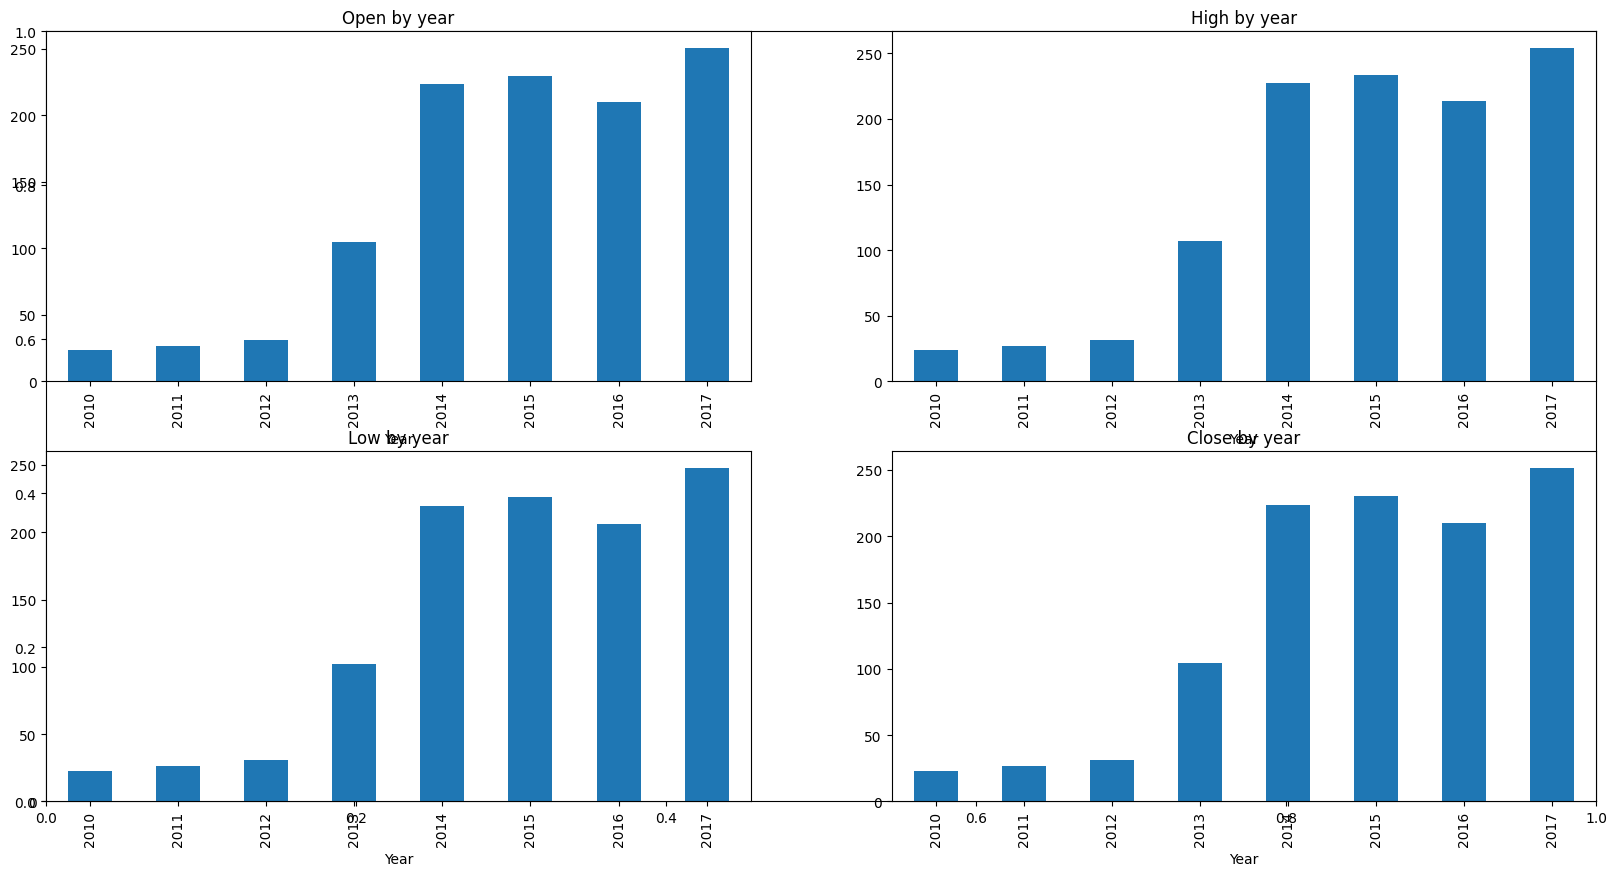

In [15]:
data_grouped = data.drop('Date', axis=1).groupby('Year').mean()
plt.subplots(figsize=(20, 10))

features =  ['Open', 'High', 'Low', 'Close']

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    data_grouped[col].plot(kind='bar')
    plt.title(f'{col} by year', fontsize=12)
plt.show()


In [16]:
data.drop('Date', axis=1).groupby('is_quarter_end').mean()

,Open,High,Low,Close,Volume,Day,Month,Year
is_quarter_end,,,,,,,,
0,130.813739,133.182620,128.257229,130.797709,4.461581e+06,15.686501,6.141208,2013.353464
1,135.679982,137.927032,133.455777,135.673269,3.891084e+06,15.657244,7.584806,2013.314488


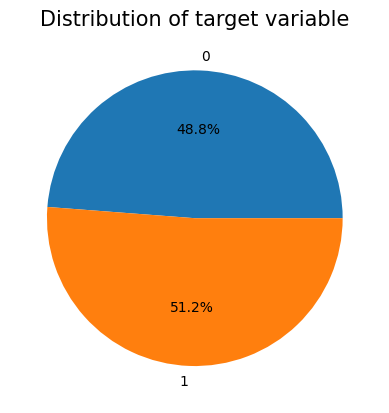

In [18]:
# Create target if it does not exist: 1 if next day's close is higher, else 0
if 'target' not in data.columns:
    data['target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)
    data = data.iloc[:-1].copy()
    data['target'] = data['target'].astype(int)

# Checking if the target variable is balanced or not
target_counts = data['target'].value_counts().sort_index()
plt.pie(target_counts.values,
        labels=target_counts.index.tolist(),
        autopct='%1.1f%%')
plt.title('Distribution of target variable', fontsize=15)
plt.show()

In [27]:
# Splitting the data into train and test sets with richer engineered features
model_data = data.copy()

# Price-action and momentum features
model_data['return_1d'] = model_data['Close'].pct_change()
model_data['return_3d'] = model_data['Close'].pct_change(3)
model_data['high_low_pct'] = (model_data['High'] - model_data['Low']) / model_data['Close']
model_data['open_close_pct'] = (model_data['Close'] - model_data['Open']) / model_data['Open']

# Trend and volatility features
model_data['ma_5'] = model_data['Close'].rolling(window=5).mean()
model_data['ma_10'] = model_data['Close'].rolling(window=10).mean()
model_data['ma_20'] = model_data['Close'].rolling(window=20).mean()
model_data['volatility_5'] = model_data['return_1d'].rolling(window=5).std()

# Lag features
model_data['close_lag_1'] = model_data['Close'].shift(1)
model_data['close_lag_2'] = model_data['Close'].shift(2)
model_data['volume_lag_1'] = model_data['Volume'].shift(1)

# Keep only complete rows after feature engineering
model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna().copy()

feature_columns = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Day', 'Month', 'Year', 'is_quarter_end',
    'return_1d', 'return_3d', 'high_low_pct', 'open_close_pct',
    'ma_5', 'ma_10', 'ma_20', 'volatility_5',
    'close_lag_1', 'close_lag_2', 'volume_lag_1'
 ]

features = model_data[feature_columns]
target = model_data['target'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

print("Data split into train and test sets successfully")
print(f"Feature count: {features.shape[1]}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into train and test sets successfully
Feature count: 20
X_train shape: (1337, 20)
X_test shape: (335, 20)
y_train shape: (1337,)
y_test shape: (335,)


In [28]:
model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1.2,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [29]:
# Predictions and evaluation
y_pred = model.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy:.4f}")
print("\nClassification report:")
print(metrics.classification_report(y_test, y_pred))

Model accuracy: 0.5463

Classification report:
              precision    recall  f1-score   support

           0       0.53      0.56      0.55       163
           1       0.56      0.53      0.54       172

    accuracy                           0.55       335
   macro avg       0.55      0.55      0.55       335
weighted avg       0.55      0.55      0.55       335

